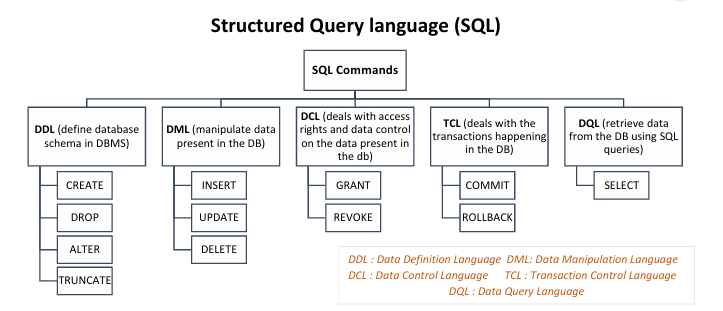

DDL

create table table_name-->

* (column_name datatype constraint)


drop table table_name-->


alter table table_name-->

* add column_name datatype constraint
* drop column column_name
* alter column column_name datatype 



DML

insert into table_name-->

* (column_names) values( column_values)

update table_name-->

* set column_name = new_value where condition

delete from table_name-->

* where condition

DQL

select column_name from table_name-->

* where condition

select * from table_name-->

* where condition

Standard Sequence of SQL Keywords
WITH (Optional)
Defines Common Table Expressions (CTEs) for reusable subqueries.

SELECT
Specifies the columns or expressions to retrieve.

FROM
Identifies the primary table(s) to query.

JOIN (with ON)
Combines data from multiple tables based on a condition.

WHERE
Filters individual rows before grouping or aggregation.

GROUP BY
Groups rows by one or more columns for aggregation.

HAVING
Filters groups after aggregation.

ORDER BY
Sorts the final result set.

LIMIT (Optional, depending on database)
Restricts the number of rows returned.

OFFSET (Optional, paired with LIMIT)
Skips a specified number of rows before applying LIMIT.

Execution Order (Logical Processing)
Databases process these keywords in a different order than they appear in the query:


FROM and JOIN (build the working table)

WHERE (filter rows)

GROUP BY (group rows)

HAVING (filter groups)

SELECT (project columns)

ORDER BY (sort results)

LIMIT/OFFSET (restrict output)

In [46]:
import mysql.connector

mydb2 = mysql.connector.connect(  #establishing the connection
    host = "localhost",
    user="root",
    passwd = "mYsql@2022",
    database = "sample2"
)

In [47]:
mydb2

In [48]:
cursor = mydb2.cursor(buffered=True)

In [ ]:
# Buffered Cursors (buffered=True)
# A buffered cursor retrieves and stores all the rows from the query result set in memory. This means that:
# The entire result set is fetched from the database and stored in memory when you execute a query.
# You can iterate over the result set multiple times without re-executing the query.
# You can use methods like fetchone(), fetchmany(), and fetchall() to retrieve rows from the result set.
# Buffered cursors are useful when:
# You need to iterate over the result set multiple times.
# You need to access rows randomly (e.g., using fetchone() and then fetchone() again).
# You're working with small to medium-sized result sets.
# Unbuffered Cursors (buffered=False)
# An unbuffered cursor retrieves rows from the query result set one at a time, without storing the entire result set in memory. This means that:
# Rows are fetched from the database as you iterate over the result set.
# You can only iterate over the result set once; if you try to iterate again, you'll need to re-execute the query.
# You can only use methods like fetchone() and fetchmany() to retrieve rows from the result set.
# Unbuffered cursors are useful when:
# You're working with very large result sets and don't want to consume excessive memory.
# You only need to iterate over the result set once.

In [4]:
cursor

Use the database 

In [6]:
cursor.execute("use sample2")

. Create table 

In [8]:
cursor.execute("""create table customer  
                    ( 
                    customer_id int AUTO_INCREMENT primary key, 
                    customer_number int not null unique check (customer_number>0), 
                    lastname varchar(30) not null, 
                    firstname varchar(30) not null, 
                    area_code int default 71000, 
                    address varchar(50), 
                    country varchar(50) default 'Malaysia' 
                    )""")

Insert values into table 

In [ ]:
cursor.execute("""insert into customer(customer_number,lastname,firstname,area_code,address,country) 
               values 
                (100,'Fang Ying','Sham','418999','sdadasfdfd',default), 
                (200,'Mei Mei','Tan',default,'adssdsadsd','Thailand'), 
                (300,'Albert','John',default,'dfdsfsdf',default)  """)

must commit after executing insertions

In [11]:
mydb2.commit()

In [19]:
# -- display all records 
cursor.execute("""select * from customer""")

fetchall() after selecting

In [18]:
cursor.fetchall()

[(1, 100, 'Fang Ying', 'Sham', 418999, 'sdadasfdfd', 'Malaysia'),
 (2, 200, 'Mei Mei', 'Tan', 71000, 'adssdsadsd', 'Thailand'),
 (3, 300, 'Albert', 'John', 71000, 'dfdsfsdf', 'Malaysia')]

display particular columns 

In [25]:
cursor.execute("""select customer_id, customer_number, lastname, firstname from customer""")

In [26]:
cursor.fetchall()

[(1, 100, 'Fang Ying', 'Sham'),
 (2, 200, 'Mei Mei', 'Tan'),
 (3, 300, 'Albert', 'John')]

Add new column to table 

ALTER table 

        add 

In [ ]:
cursor.execute("""alter table customer add phone_number varchar(20)""")

Add values to newly added 
column/ Update table

Update

set 

where

In [7]:
cursor.execute("""update customer set phone_number='1234545346' where customer_id=1""")

In [8]:
cursor.execute("""update customer set phone_number='12345645346' where customer_id=2""")

commit after update

In [9]:
mydb2.commit()

Delete a column 

Alter table

drop column 

In [10]:
cursor.execute("""alter table customer drop column phone_number""")

delete record

In [11]:
cursor.execute("""delete  
from customer  
where country='Thailand'""")

commit after delete

In [13]:
mydb2.commit()

Change data type 

In [ ]:
cursor.execute("""alter table customer alter column phone_number varchar(10)""")

 Delete table 

In [17]:
cursor.execute("""drop table customer""")

Subquery

In [49]:
import mysql.connector

mydb2 = mysql.connector.connect(  #establishing the connection
    host = "localhost",
    user="root",
    passwd = "mYsql@2022",
    database = "saleorder"
)

In [50]:
c = mydb2.cursor()

In [51]:
c

-- Subquery in Select 

In [5]:
c.execute("""SELECT EmployeeID, Salary, (SELECT AVG(Salary) from Salary) AS AllAvgSalary FROM Salary""")

In [6]:
c.fetchall()

[(1, 50000, Decimal('63900.0000')),
 (2, 60000, Decimal('63900.0000')),
 (3, 70000, Decimal('63900.0000')),
 (4, 55000, Decimal('63900.0000')),
 (5, 65000, Decimal('63900.0000')),
 (6, 75000, Decimal('63900.0000')),
 (7, 58000, Decimal('63900.0000')),
 (8, 68000, Decimal('63900.0000')),
 (9, 78000, Decimal('63900.0000')),
 (10, 60000, Decimal('63900.0000'))]

-- with Partition By 

In [7]:
c.execute("""SELECT EmployeeID, Salary, AVG(Salary) OVER () AS AllAvgSalary FROM Salary""")

In [8]:
c.fetchall()

[(1, 50000, Decimal('63900.0000')),
 (2, 60000, Decimal('63900.0000')),
 (3, 70000, Decimal('63900.0000')),
 (4, 55000, Decimal('63900.0000')),
 (5, 65000, Decimal('63900.0000')),
 (6, 75000, Decimal('63900.0000')),
 (7, 58000, Decimal('63900.0000')),
 (8, 68000, Decimal('63900.0000')),
 (9, 78000, Decimal('63900.0000')),
 (10, 60000, Decimal('63900.0000'))]

-- Subquery in From 

In [9]:
c.execute("""SELECT a.EmployeeID, AllAvgSalary 
            FROM (SELECT EmployeeID, Salary, AVG(Salary) OVER () AS 
            AllAvgSalary 
                    FROM Salary) a 
            ORDER BY a.EmployeeID""")

In [10]:
c.fetchall()

[(1, Decimal('63900.0000')),
 (2, Decimal('63900.0000')),
 (3, Decimal('63900.0000')),
 (4, Decimal('63900.0000')),
 (5, Decimal('63900.0000')),
 (6, Decimal('63900.0000')),
 (7, Decimal('63900.0000')),
 (8, Decimal('63900.0000')),
 (9, Decimal('63900.0000')),
 (10, Decimal('63900.0000'))]

-- Subquery in Where 

In [12]:
c.execute("""SELECT EmployeeID,  Salary 
        FROM Salary 
        WHERE EmployeeID in (SELECT EmployeeID FROM 
        EmployeeDemo WHERE Age > 30) 
        
        """)

In [13]:
c.fetchall()

[(3, 70000), (5, 65000), (6, 75000), (7, 58000), (9, 78000)]

In [14]:
c.execute("""SELECT EmployeeID, Salary 
            FROM Salary 
            WHERE Salary in (SELECT Max(Salary) FROM Salary) """)

In [15]:
c.fetchall()

[(9, 78000)]

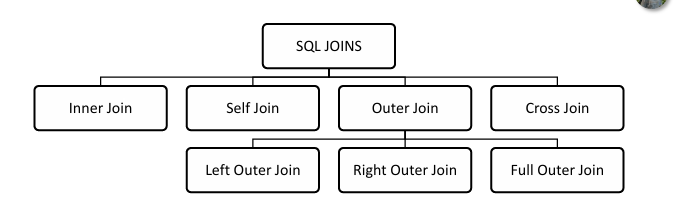

Horizontal 

getting data from multiple 
tables  
(explicit join - without using 
join command) 

In [16]:
c.execute("""select * from inventory,sale 
where sale.inventoryid=inventory.inventoryid""")

In [17]:
c.fetchall()

[(1,
  'Laptop',
  'Dell Inspiron 15 5000 Series Laptop',
  1,
  1,
  1,
  1,
  datetime.date(2022, 1, 1),
  2,
  Decimal('1000.00')),
 (2,
  'Desktop',
  'HP Pavilion Gaming Desktop',
  2,
  1,
  2,
  2,
  datetime.date(2022, 1, 5),
  1,
  Decimal('500.00')),
 (3,
  'Printer',
  'Epson Expression Home XP-4100 Printer',
  3,
  2,
  3,
  3,
  datetime.date(2022, 1, 10),
  3,
  Decimal('750.00')),
 (1,
  'Laptop',
  'Dell Inspiron 15 5000 Series Laptop',
  4,
  3,
  1,
  1,
  datetime.date(2022, 1, 15),
  1,
  Decimal('1000.00')),
 (4,
  'Scanner',
  'Canon CanoScan LiDE 300 Scanner',
  5,
  4,
  4,
  4,
  datetime.date(2022, 1, 20),
  2,
  Decimal('2000.00')),
 (5,
  'Monitor',
  'Acer R240HY 24" Full HD Monitor',
  6,
  5,
  5,
  5,
  datetime.date(2022, 1, 25),
  1,
  Decimal('1500.00')),
 (6,
  'Keyboard',
  'Logitech K120 Keyboard',
  7,
  6,
  6,
  6,
  datetime.date(2022, 2, 1),
  3,
  Decimal('1200.00')),
 (7,
  'Mouse',
  'Logitech M100 Mouse',
  8,
  7,
  7,
  7,
  datetime.dat

In [ ]:
c.execute("""select inventoryName,saleDate,saleUnitPrice,saleQuantity,saleQuantity*saleUnitPrice 
as Total_amount 
from sale,inventory 
where sale.inventoryid=inventory.inventoryid 
group by sale.inventoryid,inventoryname,saledate,salequantity,saleunitprice 
order by inventoryname""")

In [20]:
c.fetchall()

[('Desktop',
  datetime.date(2022, 1, 5),
  Decimal('500.00'),
  1,
  Decimal('500.00')),
 ('Desktop',
  datetime.date(2022, 3, 5),
  Decimal('500.00'),
  2,
  Decimal('1000.00')),
 ('Headset',
  datetime.date(2022, 2, 10),
  Decimal('2200.00'),
  1,
  Decimal('2200.00')),
 ('Headset',
  datetime.date(2022, 4, 10),
  Decimal('2200.00'),
  1,
  Decimal('2200.00')),
 ('Keyboard',
  datetime.date(2022, 2, 1),
  Decimal('1200.00'),
  3,
  Decimal('3600.00')),
 ('Keyboard',
  datetime.date(2022, 4, 1),
  Decimal('1200.00'),
  3,
  Decimal('3600.00')),
 ('Laptop',
  datetime.date(2022, 1, 1),
  Decimal('1000.00'),
  2,
  Decimal('2000.00')),
 ('Laptop',
  datetime.date(2022, 1, 15),
  Decimal('1000.00'),
  1,
  Decimal('1000.00')),
 ('Laptop',
  datetime.date(2022, 3, 1),
  Decimal('1000.00'),
  3,
  Decimal('3000.00')),
 ('Monitor',
  datetime.date(2022, 1, 25),
  Decimal('1500.00'),
  1,
  Decimal('1500.00')),
 ('Monitor',
  datetime.date(2022, 3, 20),
  Decimal('1500.00'),
  1,
  Decimal(

getting data from multiple 
tables  
(implicit join - using join 
command) 

--inner join 

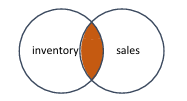

In [21]:
c.execute(""" 
select * from inventory  
inner join sale 
on sale.inventoryid=inventory.inventoryid""")

In [22]:
c.fetchall()

[(1,
  'Laptop',
  'Dell Inspiron 15 5000 Series Laptop',
  1,
  1,
  1,
  1,
  datetime.date(2022, 1, 1),
  2,
  Decimal('1000.00')),
 (2,
  'Desktop',
  'HP Pavilion Gaming Desktop',
  2,
  1,
  2,
  2,
  datetime.date(2022, 1, 5),
  1,
  Decimal('500.00')),
 (3,
  'Printer',
  'Epson Expression Home XP-4100 Printer',
  3,
  2,
  3,
  3,
  datetime.date(2022, 1, 10),
  3,
  Decimal('750.00')),
 (1,
  'Laptop',
  'Dell Inspiron 15 5000 Series Laptop',
  4,
  3,
  1,
  1,
  datetime.date(2022, 1, 15),
  1,
  Decimal('1000.00')),
 (4,
  'Scanner',
  'Canon CanoScan LiDE 300 Scanner',
  5,
  4,
  4,
  4,
  datetime.date(2022, 1, 20),
  2,
  Decimal('2000.00')),
 (5,
  'Monitor',
  'Acer R240HY 24" Full HD Monitor',
  6,
  5,
  5,
  5,
  datetime.date(2022, 1, 25),
  1,
  Decimal('1500.00')),
 (6,
  'Keyboard',
  'Logitech K120 Keyboard',
  7,
  6,
  6,
  6,
  datetime.date(2022, 2, 1),
  3,
  Decimal('1200.00')),
 (7,
  'Mouse',
  'Logitech M100 Mouse',
  8,
  7,
  7,
  7,
  datetime.dat

In [23]:
c.execute("""select 
inventoryname,saledate,saleunitprice,salequantity,saleunitprice*salequantity 
as Total_Amount 
from inventory inner join sale  
on sale.inventoryid=inventory.inventoryid  
order by inventoryname""")

In [24]:
c.fetchall()

[('Desktop',
  datetime.date(2022, 1, 5),
  Decimal('500.00'),
  1,
  Decimal('500.00')),
 ('Desktop',
  datetime.date(2022, 3, 5),
  Decimal('500.00'),
  2,
  Decimal('1000.00')),
 ('Headset',
  datetime.date(2022, 2, 10),
  Decimal('2200.00'),
  1,
  Decimal('2200.00')),
 ('Headset',
  datetime.date(2022, 4, 10),
  Decimal('2200.00'),
  1,
  Decimal('2200.00')),
 ('Keyboard',
  datetime.date(2022, 2, 1),
  Decimal('1200.00'),
  3,
  Decimal('3600.00')),
 ('Keyboard',
  datetime.date(2022, 4, 1),
  Decimal('1200.00'),
  3,
  Decimal('3600.00')),
 ('Laptop',
  datetime.date(2022, 1, 1),
  Decimal('1000.00'),
  2,
  Decimal('2000.00')),
 ('Laptop',
  datetime.date(2022, 1, 15),
  Decimal('1000.00'),
  1,
  Decimal('1000.00')),
 ('Laptop',
  datetime.date(2022, 3, 1),
  Decimal('1000.00'),
  3,
  Decimal('3000.00')),
 ('Monitor',
  datetime.date(2022, 1, 25),
  Decimal('1500.00'),
  1,
  Decimal('1500.00')),
 ('Monitor',
  datetime.date(2022, 3, 20),
  Decimal('1500.00'),
  1,
  Decimal(

--full outer join (shows everything)

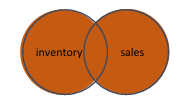

In [27]:
c.execute("""select sale.inventoryid,inventoryname 
from inventory  
full outer join sale on 
sale.inventoryid=inventory.inventoryid  
where sale.inventoryid is NULL""")

ProgrammingError: 1064 (42000): You have an error in your SQL syntax; check the manual that corresponds to your MySQL server version for the right syntax to use near 'outer join sale on 
sale.inventoryid=inventory.inventoryid  
where sale.inventor' at line 3

--left join (might have NULL value, since some inventory might not have sales) 

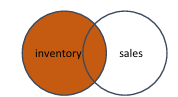

In [28]:
c.execute("""select inventory.inventoryid,inventoryname 
from inventory left join sale on 
sale.inventoryid=inventory.inventoryid""")  

In [29]:
c.fetchall()

[(1, 'Laptop'),
 (1, 'Laptop'),
 (1, 'Laptop'),
 (2, 'Desktop'),
 (2, 'Desktop'),
 (3, 'Printer'),
 (3, 'Printer'),
 (4, 'Scanner'),
 (4, 'Scanner'),
 (5, 'Monitor'),
 (5, 'Monitor'),
 (6, 'Keyboard'),
 (6, 'Keyboard'),
 (7, 'Mouse'),
 (7, 'Mouse'),
 (8, 'Headset'),
 (8, 'Headset'),
 (9, 'Webcam'),
 (9, 'Webcam'),
 (10, 'Speaker')]

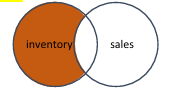

In [32]:
c.execute("""select inventory.inventoryid,inventoryname 
from inventory left join sale on 
sale.inventoryid=inventory.inventoryid  
where sale.inventoryid is NULL""")

In [33]:
c.fetchall()

[]

right join

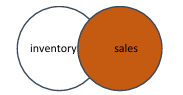

In [30]:
c.execute("""select inventory.inventoryid,inventoryname 
from inventory right join sale on 
sale.inventoryid=inventory.inventoryid""")  

In [31]:
c.fetchall()

[(1, 'Laptop'),
 (2, 'Desktop'),
 (3, 'Printer'),
 (1, 'Laptop'),
 (4, 'Scanner'),
 (5, 'Monitor'),
 (6, 'Keyboard'),
 (7, 'Mouse'),
 (8, 'Headset'),
 (9, 'Webcam'),
 (10, 'Speaker'),
 (1, 'Laptop'),
 (2, 'Desktop'),
 (3, 'Printer'),
 (4, 'Scanner'),
 (5, 'Monitor'),
 (6, 'Keyboard'),
 (7, 'Mouse'),
 (8, 'Headset'),
 (9, 'Webcam')]

-- without join: use subquery 

In [34]:
c.execute("""select inventoryid,inventoryname from inventory 
where inventoryid not in (select inventoryid from sale) """)

In [35]:
c.fetchall()    

[]

Self Join --commonly used in processing 
hierarchy 

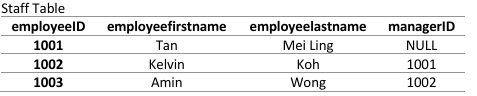

In [ ]:
c.execute("""select E.employeeID, E.employeefirstname+' '+E.employeelastname as [Full 
Name], E.managerID, , M.employeefirstname+' '+M.employeelastname as 
Manager_Name
from staff E  
inner join staff M  
on E.managerID = M.employeeID""")

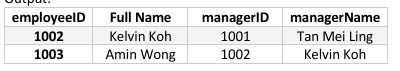

--left outer join (list all the employees) 

In [ ]:
c.execute("""select E.employeeID, E.employeefirstname+' '+E.employeelastname as [F 
Name], E.managerID, , M.employeefirstname+' '+M.employeelastname as 
Manager_Name 
from staff E  
left outer join staff M  
on E.managerID = M.employeeID""")

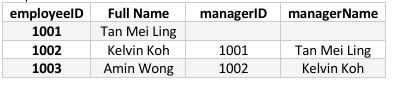

Cross Join --generate all combination of 
records (all possibility) 
(Cartesian Product) 

In [ ]:
c.execute("""select * from inventory1  
cross join inventory2""")

Vertical join

. Union

 --allow you to combine two tables 
together (but the no. of columns & 
each column’s data types for 2 tables 
must be match) --don't need common key, only need 
common attributes --merge, not showing duplicate record 

In [ ]:
c.execute("""select cust_lname,cust_fname from customer 
union  
select cust_lname,cust_fname from customer_2""")

Union all 

--merge, but show you everything, even 
the duplicate record 

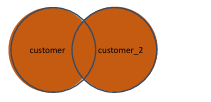

In [ ]:
c.execute("""select cust_lname,cust_fname from customer 
union all   
select cust_lname,cust_fname from customer_2""")

. Intersect 

--keep only the rows in common to 
both query --not showing duplicate record 

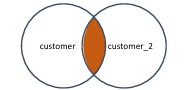

In [ ]:
c.execute("""select cust_lname,cust_fname from customer 
intersect 
select cust_lname,cust_fname from customer_2""")

In [ ]:
c.execute("""select c.cust_lname,c.cust_fname from customer c,customer_2 c2 
where c.cust_lname=c2.cust_lname and c.cust_fname=c2.cust_fname""")

. Except 

--generate only the records that are 
unique to  
the CUSTOMER table 

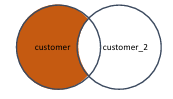

In [ ]:
c.execute("""select cust_lname,cust_fname from customer 
except 
select cust_lname,cust_fname from customer_2""")

In [ ]:
c.execute("""select cust_lname,cust_fname from customer 
where cust_lname not in  
(select cust_lname from customer_2) and  
cust_fname not in  
(select cust_fname from customer_2)""")

Table & View 

view table 

(view will be updated when 
update base) --view is a result set of SQL 
statements, ex

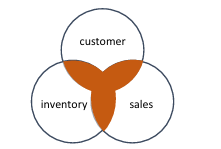

In [38]:
c.execute("""create view CustomerView as  
select customerfirstname+' '+customerlastname as Customer_Name , 
customerphonenumber, 
inventoryname,saledate,salequantity,saleunitprice,salequantity*saleunitprice 
as Total_Amount
from customer inner join sale on customer.customerid=sale.customerid inner 
join inventory  
on sale.inventoryid=inventory.inventoryid""")

In [39]:
c.fetchall()

[]

Temp table  

(temp will NOT be updated 
when update base) --a single hashtag (#) sign 
must be added in front of 
their names --used to store data 
temporarily, physically 
created in the Tempdb 
database --can perform CRUD, join, and 
some other operations like 
the persistent database tables

In [40]:
c.execute("""DROP TEMPORARY TABLE IF EXISTS temp_employee; 
            CREATE TEMPORARY TABLE temp_employee (
            JobTitle VARCHAR(100),
            EmployeesPerJob INT,
            AvgAge INT,
            AvgSalary INT
            ); 
            
            INSERT INTO temp_employee (JobTitle, EmployeesPerJob, AvgAge, AvgSalary)
            SELECT 
                emp.JobTitle,
                COUNT(emp.EmployeeID) AS EmployeesPerJob,
                CAST(AVG(emp.Age) AS SIGNED) AS AvgAge,
                CAST(AVG(sal.salary) AS SIGNED) AS AvgSalary
            FROM employeedemo emp
            JOIN Salary sal ON emp.EmployeeID = sal.EmployeeID
            WHERE emp.JobTitle = JobTitle
            GROUP BY emp.JobTitle; 
            
            Select *  From temp_employee ;""")

In [41]:
c.fetchall()

[]

CTE (Common Table 

Expression) --create temporary result set 
which is used to manipulate 
the complex sub-queries data --created in memory rather 
than Tempdb database, so 
cannot create any index on 
CTE.

In [53]:
c.execute("""WITH CTE_Employee AS  
( 
SELECT FirstName, LastName, Gender, Salary, 
COUNT(Gender) OVER (PARTITION BY Gender) AS TotalGender 
FROM EmployeeDemo ED 
JOIN Salary ES 
 ON ED.EmployeeID = ES.EmployeeID 
WHERE Salary > '45000'  
) 
 
SELECT FirstName, LastName, Gender, TotalGender 
FROM CTE_Employee 
WHERE TotalGender = (SELECT MIN(TotalGender) FROM CTE_Employee)""")

In [54]:
c.fetchall()

[('Jane', 'Smith', 'Female', 5),
 ('Alice', 'Williams', 'Female', 5),
 ('Emma', 'Miller', 'Female', 5),
 ('Sophia', 'Moore', 'Female', 5),
 ('Mia', 'Anderson', 'Female', 5),
 ('John', 'Doe', 'Male', 5),
 ('Bob', 'Johnson', 'Male', 5),
 ('Mike', 'Davis', 'Male', 5),
 ('Tom', 'Wilson', 'Male', 5),
 ('Oliver', 'Taylor', 'Male', 5)]

Duplicate Table 

In [ ]:
c.execute("""select customerfirstname+' '+customerlastname as [Customer Name] , 
customerphonenumber, 
inventoryname,saledate,salequantity,saleunitprice,salequantity*saleunitprice 
as [Total Amount] into customerRec 
from customer inner join sale on customer.customerid=sale.customerid inner 
join inventory  
on sale.inventoryid=inventory.inventoryid 
order by customerfirstname +' '+ customerlastname,inventoryname""") 

SQL RANKS 

ROW_NUMBER() 

get a unique sequential number for each row --get different ranks for the row having similar values

In [56]:
c.execute("""SELECT *,  
       ROW_NUMBER() OVER(ORDER BY Salary DESC) SalaryRank 
FROM Salary""")

In [57]:
c.fetchall()

[(9, 78000, 1),
 (6, 75000, 2),
 (3, 70000, 3),
 (8, 68000, 4),
 (5, 65000, 5),
 (2, 60000, 6),
 (10, 60000, 7),
 (7, 58000, 8),
 (4, 55000, 9),
 (1, 50000, 10)]

RANK() 

-specify rank for each row in the result set --use PARTITION BY to performs calculation on each group --each subset get rank as per Salary in descending order

In [58]:
c.execute("""SELECT *,  
       RANK() OVER(PARTITION BY gender ORDER BY age DESC) 
ageRank 
FROM EmployeeDemo 
ORDER BY gender, ageRank""")

In [59]:
c.fetchall()

[(6, 'Emma', 'Miller', 32, 'Female', 'HR Generalist', 1),
 (8, 'Sophia', 'Moore', 29, 'Female', 'Graphic Designer', 2),
 (2, 'Jane', 'Smith', 28, 'Female', 'Data Analyst', 3),
 (10, 'Mia', 'Anderson', 27, 'Female', 'Customer Support Specialist', 4),
 (4, 'Alice', 'Williams', 25, 'Female', 'Marketing Specialist', 5),
 (5, 'Mike', 'Davis', 40, 'Male', 'Sales Manager', 1),
 (7, 'Tom', 'Wilson', 38, 'Male', 'IT Manager', 2),
 (9, 'Oliver', 'Taylor', 36, 'Male', 'Finance Analyst', 3),
 (3, 'Bob', 'Johnson', 35, 'Male', 'Product Manager', 4),
 (1, 'John', 'Doe', 30, 'Male', 'Software Engineer', 5)]

-- get SAME ranks for the row having similar values 

In [60]:
c.execute("""SELECT *,  
       RANK() OVER(ORDER BY Salary DESC) SalaryRank 
FROM Salary 
ORDER BY SalaryRank """)

In [61]:
c.fetchall()

[(9, 78000, 1),
 (6, 75000, 2),
 (3, 70000, 3),
 (8, 68000, 4),
 (5, 65000, 5),
 (2, 60000, 6),
 (10, 60000, 6),
 (7, 58000, 8),
 (4, 55000, 9),
 (1, 50000, 10)]

DENSE_RANK() 

if have duplicate values, SQL assigns different ranks to those rows.  -- will get the same rank for duplicate or similar values

In [62]:
c.execute("""SELECT *,  
    DENSE_RANK() OVER(ORDER BY Salary DESC) SalaryRank 
FROM Salary 
ORDER BY SalaryRank""")

In [63]:
c.fetchall()

[(9, 78000, 1),
 (6, 75000, 2),
 (3, 70000, 3),
 (8, 68000, 4),
 (5, 65000, 5),
 (2, 60000, 6),
 (10, 60000, 6),
 (7, 58000, 7),
 (4, 55000, 8),
 (1, 50000, 9)]

In [ ]:
c.execute("""SELECT *,  
       RANK() OVER(PARTITION BY JobTitle ORDER 
BY Salary DESC) SalaryRank 
FROM Salary 
ORDER BY JobTitle, SalaryRank""")

In [ ]:
c.execute("""SELECT *,  
       DENSE_RANK() OVER(PARTITION BY JobTitle 
ORDER BY Salary DESC) SalaryRank 
FROM EmployeeSalary 
ORDER BY JobTitle, SalaryRank""")

NTILE() 

- can specify required how many group of result, and it will rank accordingly 

In [66]:
c.execute("""SELECT *,  
       NTILE(3) OVER(ORDER BY Salary DESC) SalaryRank 
FROM Salary 
ORDER BY SalaryRank""")   

In [67]:
c.fetchall()

[(9, 78000, 1),
 (6, 75000, 1),
 (3, 70000, 1),
 (8, 68000, 1),
 (5, 65000, 2),
 (2, 60000, 2),
 (10, 60000, 2),
 (7, 58000, 3),
 (4, 55000, 3),
 (1, 50000, 3)]

In [ ]:
c.execute("""SELECT *,  
       NTILE(3) OVER(PARTITION BY JobTitle ORDER BY Salary DESC) 
SalaryRank 
FROM EmployeeSalary 
ORDER BY JobTitle, SalaryRank;""")

1. Write the query to show the 
invoice number, the customer 
number, the customer  
name, the invoice date, and the 
invoice amount for all 
customers with a customer 
balance  
of $1,000 or more. 

In [ ]:
c.execute("""number, the customer  
name, the invoice date, and the 
invoice amount for all 
customers with a customer 
balance  
of $1,000 or more. 
select 
invoice_num,c.cust_num,c.cust_lname,c.cust_fname,inv_date,inv_amount  
from customer c, invoice 
where c.cust_num=invoice.cust_num and cust_balance>=1000 

select invoice_num,c.cust_num,cust_lname+' '+cust_fname as 
[Name],inv_date,inv_amount 
from customer c join invoice i  
on c.cust_num=i.cust_num 
where cust_balance>=1000""")


2. ISNULL(expression, value) --expression: to test whether is 
NULL, value: to return if 
expression is NULL 

ParcelID is same, but UniqueID is different; can assume that if the ParcelID is 
same, the Property Address will be same 

In [ ]:
c.execute("""Select a.ParcelID, a.PropertyAddress, b.ParcelID, 
b.PropertyAddress, 
ISNULL(a.PropertyAddress,b.PropertyAddress) 
From NashvilleHousing a 
JOIN NashvilleHousing b 
 on a.ParcelID = b.ParcelID 
 AND a.[UniqueID] <> b.[UniqueID] 
Where a.PropertyAddress is null""")

-- Update record 

In [ ]:
c.execute("""Update a 
SET PropertyAddress = 
ISNULL(a.PropertyAddress,b.PropertyAddress) 
From NashvilleHousing a 
JOIN NashvilleHousing b 
 on a.ParcelID = b.ParcelID 
 AND a.[UniqueID] <> b.[UniqueID] 
Where a.PropertyAddress is null""")

3. Split by delimiter 
 
❖ SUBSTRING(string, start, 
length) 
 
❖ CHARINDEX(substring, 
string, start) 
 
❖ LEN(string) 

In [ ]:
c.execute("""SELECT PropertyAddress, 
SUBSTRING(PropertyAddress, 1, CHARINDEX(',', 
PropertyAddress) -1 ) as Address 
, SUBSTRING(PropertyAddress, CHARINDEX(',', 
PropertyAddress) + 1 , LEN(PropertyAddress)) as City 
From NashvilleHousing

ALTER TABLE NashvilleHousing 
Add PropertySplitAddress Nvarchar(255); 
 
ALTER TABLE NashvilleHousing 
Add PropertySplitCity Nvarchar(255); 

Update NashvilleHousing 
SET PropertySplitAddress = SUBSTRING(PropertyAddress, 1, 
CHARINDEX(',', PropertyAddress) -1 ) 
 
Update NashvilleHousing 
SET PropertySplitCity = SUBSTRING(PropertyAddress, 
CHARINDEX(',', PropertyAddress) + 1 , LEN(PropertyAddress))""")

PARSENAME('object_name'
 , object_piece) --numbering works from 
right to left 
 
❖ REPLACE(string, old_string, 
new_string) 

In [ ]:
c.execute("""
Select OwnerAddress, 
PARSENAME(REPLACE(OwnerAddress, ',', '.') , 3) 
,PARSENAME(REPLACE(OwnerAddress, ',', '.') , 2) 
,PARSENAME(REPLACE(OwnerAddress, ',', '.') , 1) 
From NashvilleHousing

ALTER TABLE NashvilleHousing 
Add OwnerSplitAddress Nvarchar(255); 
ALTER TABLE NashvilleHousing 
Add OwnerSplitCity Nvarchar(255); 
ALTER TABLE NashvilleHousing 
Add OwnerSplitState Nvarchar(255); 
 
Update NashvilleHousing 
SET OwnerSplitAddress = PARSENAME(REPLACE(OwnerAddress, 
',', '.') , 3) 
 
Update NashvilleHousing 
SET OwnerSplitCity = PARSENAME(REPLACE(OwnerAddress, ',', 
'.') , 2) 
 
Update NashvilleHousing 
SET OwnerSplitState = PARSENAME(REPLACE(OwnerAddress, ',', 
'.') , 1) """)

Remove duplicate records 

In [ ]:
c.execute("""WITH RowNumCTE AS( 
Select *, 
 ROW_NUMBER() OVER ( 
 PARTITION BY ParcelID, 
    PropertyAddress, 
    SalePrice, 
    SaleDate, 
    LegalReference 
    ORDER BY UniqueID) as row_num 
From NashvilleHousing 
order by ParcelID 
) 

Select * From RowNumCTE 
Where row_num > 1 
Order by PropertyAddress""")